In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flowers-dataset/sample_submission.csv
/kaggle/input/flowers-dataset/Testing_set_flower.csv
/kaggle/input/flowers-dataset/LICENSE.txt
/kaggle/input/flowers-dataset/test/Image_747.jpg
/kaggle/input/flowers-dataset/test/Image_561.jpg
/kaggle/input/flowers-dataset/test/Image_345.jpg
/kaggle/input/flowers-dataset/test/Image_844.jpg
/kaggle/input/flowers-dataset/test/Image_270.jpg
/kaggle/input/flowers-dataset/test/Image_526.jpg
/kaggle/input/flowers-dataset/test/Image_322.jpg
/kaggle/input/flowers-dataset/test/Image_860.jpg
/kaggle/input/flowers-dataset/test/Image_574.jpg
/kaggle/input/flowers-dataset/test/Image_879.jpg
/kaggle/input/flowers-dataset/test/Image_22.jpg
/kaggle/input/flowers-dataset/test/Image_486.jpg
/kaggle/input/flowers-dataset/test/Image_608.jpg
/kaggle/input/flowers-dataset/test/Image_592.jpg
/kaggle/input/flowers-dataset/test/Image_352.jpg
/kaggle/input/flowers-dataset/test/Image_687.jpg
/kaggle/input/flowers-dataset/test/Image_278.jpg
/kaggle/input/flowers

In [2]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping
import kagglehub
import warnings
warnings.filterwarnings('ignore')

2025-05-23 05:26:48.850026: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747978009.122819      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747978009.199779      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.18.0


In [4]:
path = kagglehub.dataset_download("imsparsh/flowers-dataset")
extract_path = '/kaggle/input/flowers-dataset'

In [5]:
train_dir = os.path.join(extract_path, 'train')
validation_dir = os.path.join(extract_path, 'test')

In [6]:
# Validate paths
if not os.path.exists(train_dir) or not os.path.exists(validation_dir):
    print("❌ Training or validation directories are missing!")
else:
    print("✅ Training and validation directories exist.")

✅ Training and validation directories exist.


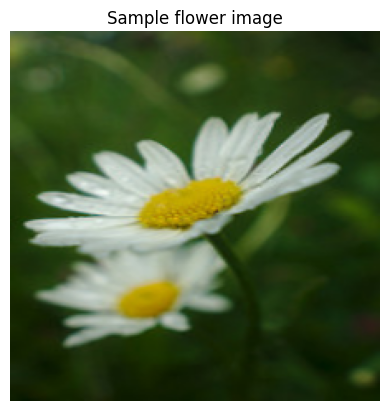

In [7]:
# Show sample image
sample_image_path = os.path.join(train_dir, 'daisy', os.listdir(os.path.join(train_dir, 'daisy'))[0])
img = cv2.imread(sample_image_path)
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    plt.imshow(img_resized)
    plt.axis("off")
    plt.title("Sample flower image")
    plt.show()
else:
    print("❌ Failed to load sample image")

In [8]:
img_size = (224, 224)
batch_size = 32

In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 2198 images belonging to 5 classes.


In [11]:
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 548 images belonging to 5 classes.


In [12]:
class_names = list(train_generator.class_indices.keys())


In [13]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

2025-05-23 05:27:10.295044: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(512)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

output = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [15]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=1000,
    decay_rate=0.9
)


In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [17]:

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [18]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.3592 - loss: 1.6940 - val_accuracy: 0.7920 - val_loss: 0.9155
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.7028 - loss: 0.8241 - val_accuracy: 0.8193 - val_loss: 0.6229
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7659 - loss: 0.6404 - val_accuracy: 0.8431 - val_loss: 0.5038
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8307 - loss: 0.5143 - val_accuracy: 0.8686 - val_loss: 0.4099
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8441 - loss: 0.4653 - val_accuracy: 0.8777 - val_loss: 0.3619
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8486 - loss: 0.4339 - val_accuracy: 0.8796 - val_loss: 0.3472
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8618 - loss: 0.4000 - val_accuracy: 0.8777 - val_loss: 0.3363
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8643 - loss: 0.3728 - val_accuracy: 0.8996 - v

In [19]:
test_loss, test_acc = model.evaluate(validation_generator)
print(f"\n✅ Model Test Accuracy: {test_acc * 100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9153 - loss: 0.2412

✅ Model Test Accuracy: 90.15%


18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step


<Figure size 800x800 with 0 Axes>

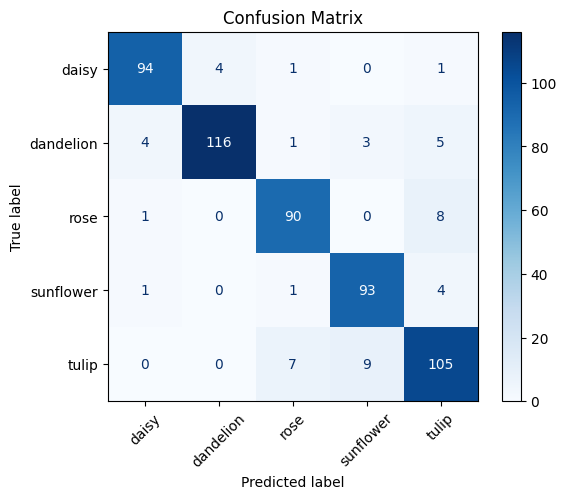

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Predict on validation set
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()



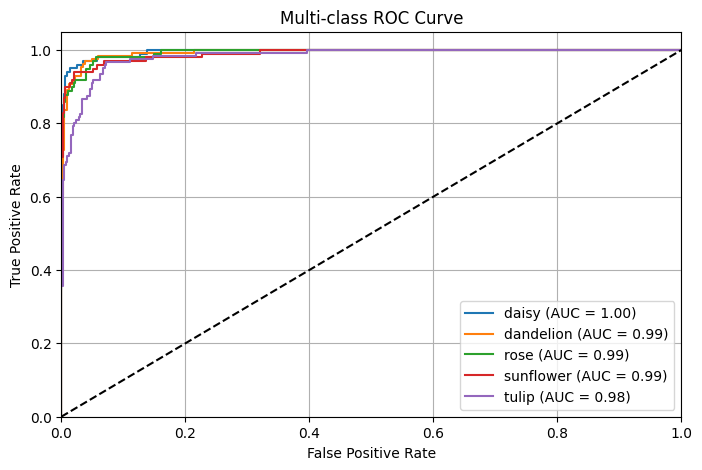

In [21]:
from sklearn.metrics import roc_auc_score

# Binarize the true labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 5))
for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [22]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("📊 Classification Report:\n")
print(report)


📊 Classification Report:

              precision    recall  f1-score   support

       daisy       0.94      0.94      0.94       100
   dandelion       0.97      0.90      0.93       129
        rose       0.90      0.91      0.90        99
   sunflower       0.89      0.94      0.91        99
       tulip       0.85      0.87      0.86       121

    accuracy                           0.91       548
   macro avg       0.91      0.91      0.91       548
weighted avg       0.91      0.91      0.91       548

